In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler


Task 1

In [2]:
df = pd.read_csv("d:\\UET Mardan\\6th Semester\\Machine Learning\\Lab Tasks\\Titanic-Dataset.csv")

print(df.head(10))

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr. Timothy J    male  54

Task 2


In [3]:
print("\nMissing Values:\n")
print(df.isnull().sum())



Missing Values:

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Task 3

In [4]:
for col in ["Age", "Fare"]:
    print(f"\n{col} Statistics:")
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])


Age Statistics:
Mean: 29.69911764705882
Median: 28.0
Mode: 24.0

Fare Statistics:
Mean: 32.204207968574636
Median: 14.4542
Mode: 8.05


Task 4

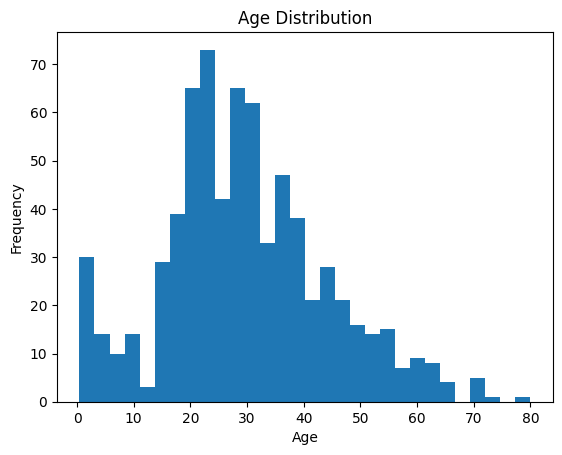

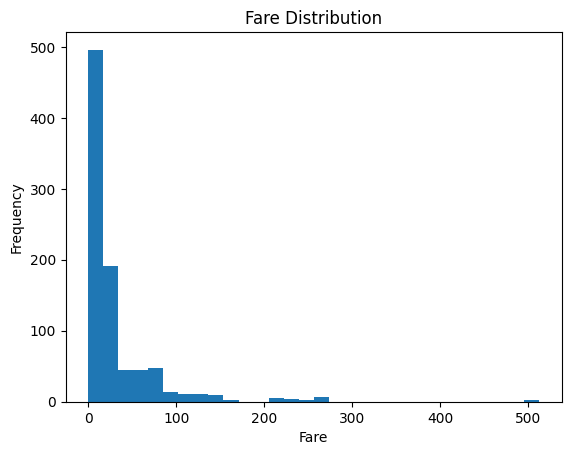

In [5]:
plt.figure()
plt.hist(df["Age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(df["Fare"], bins=30)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

Task 5

In [6]:
print("\nBefore Encoding (Sex):")
print(df["Sex"].head())

le = LabelEncoder()
df["Sex_Encoded"] = le.fit_transform(df["Sex"])

print("\nAfter Encoding (Sex):")
print(df[["Sex", "Sex_Encoded"]].head())


Before Encoding (Sex):
0      male
1    female
2    female
3    female
4      male
Name: Sex, dtype: str

After Encoding (Sex):
      Sex  Sex_Encoded
0    male            1
1  female            0
2  female            0
3  female            0
4    male            1


Task 6

In [7]:
embarked_dummies = pd.get_dummies(df["Embarked"], drop_first=True)
df = pd.concat([df, embarked_dummies], axis=1)

print("\nOne-Hot Encoded Embarked Columns:")
print(df[["Embarked"] + list(embarked_dummies.columns)].head())


One-Hot Encoded Embarked Columns:
  Embarked      Q      S
0        S  False   True
1        C  False  False
2        S  False   True
3        S  False   True
4        S  False   True


Task 7


Correlation Matrix:

               Age      Fare    Pclass  Survived
Age       1.000000  0.096067 -0.369226 -0.077221
Fare      0.096067  1.000000 -0.549500  0.257307
Pclass   -0.369226 -0.549500  1.000000 -0.338481
Survived -0.077221  0.257307 -0.338481  1.000000


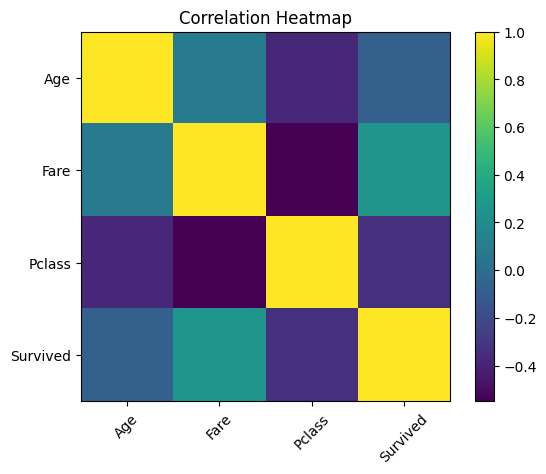

In [8]:
corr_columns = ["Age", "Fare", "Pclass", "Survived"]
corr_matrix = df[corr_columns].corr()

print("\nCorrelation Matrix:\n")
print(corr_matrix)

plt.figure()
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_columns)), corr_columns, rotation=45)
plt.yticks(range(len(corr_columns)), corr_columns)
plt.title("Correlation Heatmap")
plt.show()

Task 8


Original vs Min-Max Scaled Fare:
      Fare  Fare_Scaled
0   7.2500     0.014151
1  71.2833     0.139136
2   7.9250     0.015469
3  53.1000     0.103644
4   8.0500     0.015713


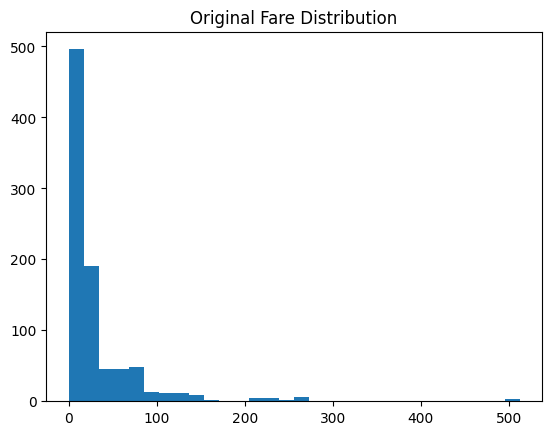

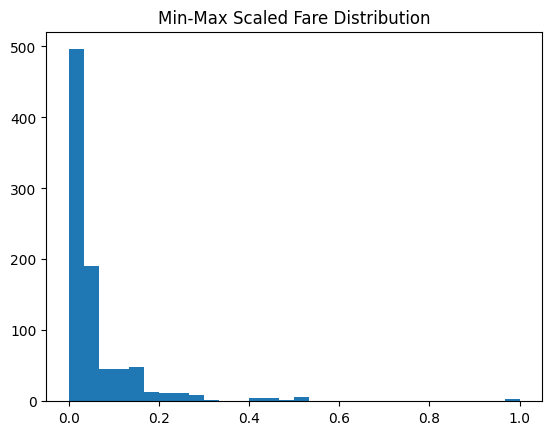

In [9]:
mms = MinMaxScaler()
df["Fare_Scaled"] = mms.fit_transform(df[["Fare"]])

print("\nOriginal vs Min-Max Scaled Fare:")
print(df[["Fare", "Fare_Scaled"]].head())

plt.figure()
plt.hist(df["Fare"], bins=30)
plt.title("Original Fare Distribution")
plt.show()

plt.figure()
plt.hist(df["Fare_Scaled"], bins=30)
plt.title("Min-Max Scaled Fare Distribution")
plt.show()

Task 9


Standardized Age Mean: 2.388378943731429e-16
Standardized Age Std: 1.000701016559981


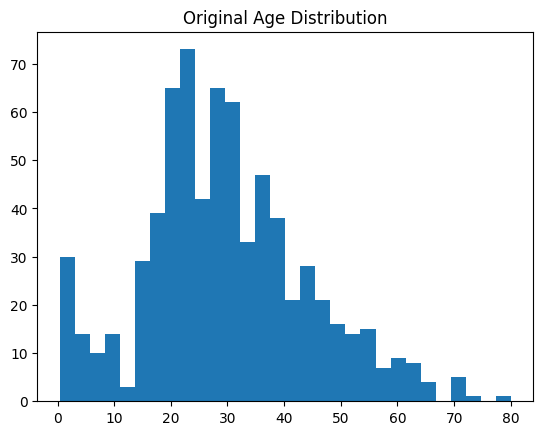

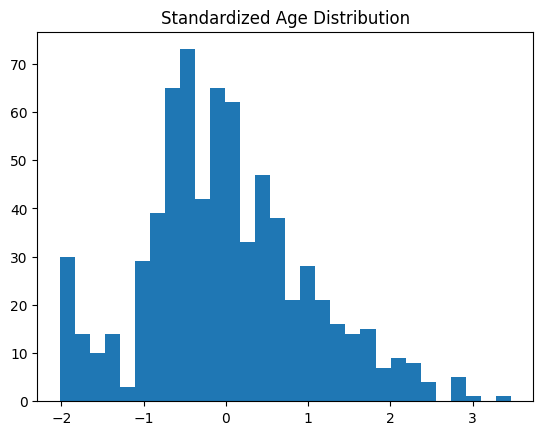

In [10]:
ss = StandardScaler()
df["Age_Standardized"] = ss.fit_transform(df[["Age"]])

print("\nStandardized Age Mean:", df["Age_Standardized"].mean())
print("Standardized Age Std:", df["Age_Standardized"].std())

plt.figure()
plt.hist(df["Age"], bins=30)
plt.title("Original Age Distribution")
plt.show()

plt.figure()
plt.hist(df["Age_Standardized"], bins=30)
plt.title("Standardized Age Distribution")
plt.show()